<a href="https://colab.research.google.com/github/Richa0416/research_cropfailure/blob/main/cropdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import shap

In [3]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
df = df.dropna()

In [6]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [8]:
def classify_failure(row):
    if row['rainfall'] < 50 or row['temperature'] > 40:
        return 1   # Failure
    else:
        return 0   # Success

df['crop_failure'] = df.apply(classify_failure, axis=1)

In [11]:
pests = ["Aphid", "Locust", "Beetle", "None"]
severity = ["Low", "Medium", "High"]

df['pest_type'] = [random.choice(pests) for _ in range(len(df))]
df['pest_severity'] = [random.choice(severity) for _ in range(len(df))]

In [12]:
df['pest_type'] = le.fit_transform(df['pest_type'])
df['pest_severity'] = le.fit_transform(df['pest_severity'])

In [38]:
X = df.drop(['crop_failure', 'label', 'rainfall', 'temperature'], axis=1)
y = df['crop_failure']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9113636363636364


In [32]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

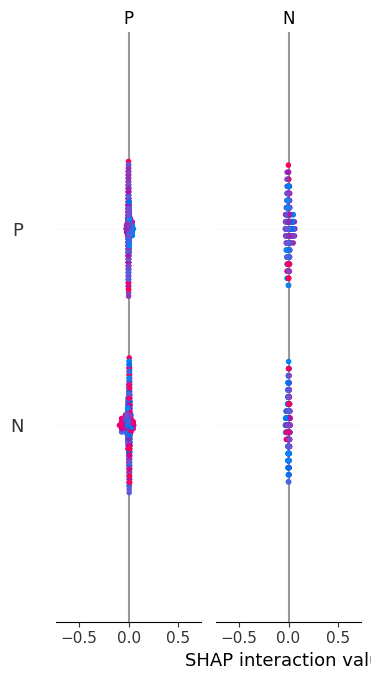

In [33]:
shap.summary_plot(shap_values, X_test)

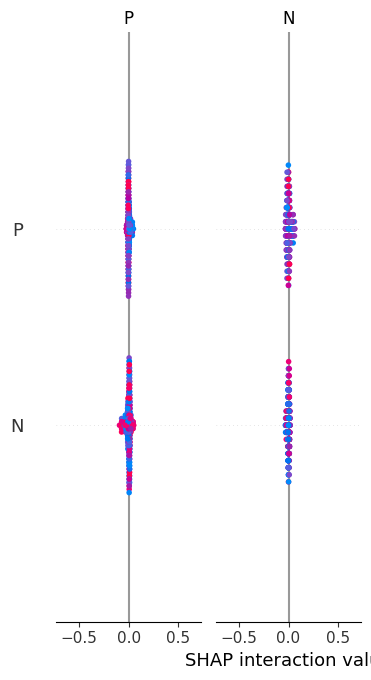

In [34]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [35]:
print(y_pred[:10])

[1 1 1 0 0 0 0 0 0 0]


In [36]:
result = X_test.copy()
result['Actual'] = y_test
result['Predicted'] = y_pred

print(result.head(10))

        N    P    K  temperature   humidity        ph    rainfall  pest_type  \
1451  101   17   47    29.494014  94.729813  6.185053   26.308209          1   
1334   98    8   51    26.179346  86.522581  6.259336   49.430510          3   
1761   59   62   49    43.360515  93.351916  6.941497  114.778071          2   
1735   44   60   55    34.280461  90.555616  6.825371   98.540477          0   
1576   30  137  200    22.914300  90.704756  5.603413  118.604465          0   
1110   18   19   27    27.755187  52.346058  4.772386   94.112133          0   
1594   35  145  195    22.039115  94.580758  6.231950  110.980401          1   
530    22   44   24    24.309351  56.329383  6.030447   58.995363          1   
651    11   46   24    27.652802  89.806506  6.459252   56.525580          0   
819     3   78   18    20.213682  68.652577  6.887130   50.897330          2   

      pest_severity  Actual  Predicted  
1451              2       1          1  
1334              2       1          

In [43]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9113636363636364


In [44]:
print(X.columns)

Index(['N', 'P', 'K', 'humidity', 'ph', 'pest_type', 'pest_severity'], dtype='object')
